In [4]:
# ============================================================
# CELL 2: LOAD TRAINED MODEL + TOKENIZER
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# Paths to saved model
MODEL_BASE = "meta-llama/Llama-3.2-3B-Instruct"
FINAL_MODEL_PATH = "/kaggle/input/datasets/sameaha/llama-3-2-trained-model/final_model"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_BASE,
    device_map="auto",
    torch_dtype=torch.float16,
    use_cache=False,
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, FINAL_MODEL_PATH)
model = model.merge_and_unload()  # Merge LoRA into base for faster inference
model.eval()

print(f"✅ Model loaded on: {model.device}")

Loading tokenizer...
Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapter...
✅ Model loaded on: cuda:0


In [5]:
# ============================================================
# CELL 3: LOAD KNOWLEDGE BASE DATASET
# ============================================================
import pandas as pd
import numpy as np

# Dataset path
TRAIN_FILE = '/kaggle/input/datasets/sameaha/calidebug/calidebug_train_FINAL.csv'

print("Loading training dataset as knowledge base...")
df = pd.read_csv(TRAIN_FILE)
print(f"✅ Loaded {len(df):,} examples")

# Create combined text for embedding
def create_kb_text(row):
    return f"""Bug Type: {row.get('bug_type', 'unknown')}
Language: {row.get('language', 'python')}
Buggy Code:
{row.get('buggy_code', '')}
Fixed Code:
{row.get('fixed_code', '')}"""

df['kb_text'] = df.apply(create_kb_text, axis=1)
print(f"✅ Prepared {len(df)} knowledge base entries")

Loading training dataset as knowledge base...
✅ Loaded 3,216 examples
✅ Prepared 3216 knowledge base entries


In [6]:
# ============================================================
# CELL 4: BUILD & SAVE FAISS INDEX (RUN ONCE)
# ============================================================
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pickle
import os

INDEX_PATH = "/kaggle/working/faiss_index.bin"
METADATA_PATH = "/kaggle/working/faiss_metadata.pkl"

# Load embedding model
print("Loading embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device='cuda' if torch.cuda.is_available() else 'cpu')

# Create embeddings
print("Creating embeddings for knowledge base...")
texts = df['kb_text'].tolist()
embeddings = embedder.encode(texts, show_progress_bar=True, batch_size=32)
embeddings = embeddings.astype('float32')

# Build FAISS index
print("Building FAISS index...")
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner product = cosine similarity for normalized vectors
faiss.normalize_L2(embeddings)
index.add(embeddings)

# Save index and metadata
print("Saving index...")
faiss.write_index(index, INDEX_PATH)
with open(METADATA_PATH, 'wb') as f:
    pickle.dump({
        'buggy_code': df['buggy_code'].tolist(),
        'fixed_code': df['fixed_code'].tolist(),
        'bug_type': df['bug_type'].tolist(),
        'language': df['language'].tolist(),
    }, f)

print(f"✅ FAISS index saved to {INDEX_PATH}")
print(f"✅ Metadata saved to {METADATA_PATH}")
print(f"   Index size: {index.ntotal} vectors")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Creating embeddings for knowledge base...


Batches:   0%|          | 0/101 [00:00<?, ?it/s]

Building FAISS index...
Saving index...
✅ FAISS index saved to /kaggle/working/faiss_index.bin
✅ Metadata saved to /kaggle/working/faiss_metadata.pkl
   Index size: 3216 vectors


In [7]:
# ============================================================
# CELL 5: LOAD FAISS INDEX
# ============================================================
import faiss
import pickle

INDEX_PATH = "/kaggle/working/faiss_index.bin"
METADATA_PATH = "/kaggle/working/faiss_metadata.pkl"

print("Loading FAISS index...")
index = faiss.read_index(INDEX_PATH)

with open(METADATA_PATH, 'rb') as f:
    metadata = pickle.load(f)

print(f"✅ Loaded index with {index.ntotal} vectors")
print(f"✅ Loaded {len(metadata['buggy_code'])} metadata entries")

Loading FAISS index...
✅ Loaded index with 3216 vectors
✅ Loaded 3216 metadata entries


In [8]:
# ============================================================
# CELL 6: RETRIEVAL FUNCTION
# ============================================================
from sentence_transformers import SentenceTransformer

# Load embedder if not already loaded
try:
    embedder
except NameError:
    embedder = SentenceTransformer('all-MiniLM-L6-v2', device='cuda' if torch.cuda.is_available() else 'cpu')

def retrieve_similar_examples(query_code, k=4):
    """
    Retrieve top-k similar buggy code examples from knowledge base.
    Returns list of dicts with buggy_code, fixed_code, bug_type, language.
    """
    # Create query text
    query_text = f"Buggy Code:\n{query_code}"
    
    # Get embedding
    query_embedding = embedder.encode([query_text], convert_to_numpy=True)
    query_embedding = query_embedding.astype('float32')
    faiss.normalize_L2(query_embedding)
    
    # Search
    scores, indices = index.search(query_embedding, k)
    
    # Build results
    results = []
    for i, idx in enumerate(indices[0]):
        if idx < len(metadata['buggy_code']):
            results.append({
                'buggy_code': metadata['buggy_code'][idx],
                'fixed_code': metadata['fixed_code'][idx],
                'bug_type': metadata['bug_type'][idx],
                'language': metadata['language'][idx],
                'score': float(scores[0][i]),
            })
    
    return results

In [9]:
# ============================================================
# CELL 7: PROMPT CONSTRUCTION WITH RETRIEVED EXAMPLES
# ============================================================
def build_rag_prompt(buggy_code, retrieved_examples, language='python'):
    """
    Build prompt with retrieved examples and the target buggy code.
    """
    prompt = "You are an expert code debugger.\n\n"
    
    # Add retrieved examples as context
    if retrieved_examples:
        prompt += "Here are similar buggy code examples with their fixes:\n\n"
        for i, ex in enumerate(retrieved_examples, 1):
            prompt += f"Example {i} (Bug Type: {ex['bug_type']}):\n"
            prompt += f"Buggy Code:\n```{language}\n{ex['buggy_code']}\n```\n"
            prompt += f"Fixed Code:\n```{language}\n{ex['fixed_code']}\n```\n\n"
        
        prompt += "Now fix the following buggy code based on the above examples:\n\n"
    else:
        prompt += "Fix the following buggy code:\n\n"
    
    # Add target code
    prompt += f"Buggy Code:\n```{language}\n{buggy_code}\n```\n\n"
    prompt += "Fixed Code:"
    
    return prompt

def generate_fix(buggy_code, k=4, max_new_tokens=500, temperature=0.1):
    """
    Generate fixed code using RAG.
    """
    # Retrieve similar examples
    retrieved = retrieve_similar_examples(buggy_code, k=k)
    
    # Build prompt
    prompt = build_rag_prompt(buggy_code, retrieved)
    
    # Tokenize and generate
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=(temperature > 0),
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    # Decode only new tokens
    response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(response_tokens, skip_special_tokens=True)
    
    return response, retrieved

In [10]:
# ============================================================
# CELL 8: BATCH INFERENCE ON TEST SET
# ============================================================
from tqdm import tqdm
import re

TEST_FILE = '/kaggle/input/datasets/sameaha/calidebug/calidebug_test_FINAL.csv'

print("Loading test dataset...")
test_df = pd.read_csv(TEST_FILE)
print(f"✅ Loaded {len(test_df):,} test examples")

# Limit to first N for testing (adjust as needed)
TEST_LIMIT = 50
test_df = test_df.head(TEST_LIMIT)

print(f"🔍 Running RAG inference on {len(test_df)} test examples...")
print("⚠️ This may take 20-30 minutes depending on GPU...")

results = []
predictions = []
references = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Inference"):
    buggy = row['buggy_code']
    expected = row['fixed_code']
    
    # Generate with RAG
    response, retrieved = generate_fix(buggy, k=4, max_new_tokens=400, temperature=0.1)
    
    # Clean up: extract code block if present
    code_blocks = re.findall(r'```python\n(.*?)```', response, re.DOTALL)
    if code_blocks:
        response_clean = code_blocks[0].strip()
    else:
        # Try to extract code without markdown
        code_blocks = re.findall(r'```\n(.*?)```', response, re.DOTALL)
        if code_blocks:
            response_clean = code_blocks[0].strip()
        else:
            response_clean = response.strip()
    
    predictions.append(response_clean)
    references.append(expected)
    
    results.append({
        'sample_id': idx,
        'bug_type': row.get('bug_type', 'unknown'),
        'exact_match': (expected.strip() == response_clean.strip()),
        'response_length': len(response_clean),
        'reference_length': len(expected),
        'num_retrieved': len(retrieved),
        'top_retrieved_score': retrieved[0]['score'] if retrieved else 0,
    })

print(f"✅ Completed {len(results)} inferences")

Loading test dataset...
✅ Loaded 1,072 test examples
🔍 Running RAG inference on 50 test examples...
⚠️ This may take 20-30 minutes depending on GPU...


Inference: 100%|██████████| 50/50 [08:06<00:00,  9.73s/it]

✅ Completed 50 inferences


In [11]:
# ============================================================
# CELL 9: MANUAL INFERENCE (HARDCODED EXAMPLE)
# ============================================================
print("="*60)
print("🧪 MANUAL INFERENCE WITH RAG")
print("="*60)

# Hardcoded buggy code example
hardcoded_buggy = """def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count"""

print("📝 Buggy Code:")
print(hardcoded_buggy)
print("\n" + "="*60)

# Generate with RAG
response, retrieved = generate_fix(hardcoded_buggy, k=4, max_new_tokens=300, temperature=0.1)

print("\n📋 Retrieved Examples (top-4):")
for i, ex in enumerate(retrieved, 1):
    print(f"\nExample {i} (Score: {ex['score']:.4f})")
    print(f"Bug Type: {ex['bug_type']}")
    print(f"Buggy: {ex['buggy_code'][:80]}...")
    print(f"Fixed: {ex['fixed_code'][:80]}...")

print("\n" + "="*60)
print("🔧 Generated Fix:")
print("="*60)
print(response)
print("="*60)

# Extract code if present
import re
code_blocks = re.findall(r'```python\n(.*?)```', response, re.DOTALL)
if code_blocks:
    print("\n✅ Extracted Code:")
    print(code_blocks[0].strip())
else:
    print("\n💡 Response is code directly:")
    print(response)

🧪 MANUAL INFERENCE WITH RAG
📝 Buggy Code:
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count


📋 Retrieved Examples (top-4):

Example 1 (Score: 0.5957)
Bug Type: Algorithm
Buggy: import itertools
import statistics
# Refined function after importing required l...
Fixed: import itertools
import statistics
# Refined function after importing required l...

Example 2 (Score: 0.5944)
Bug Type: multiple error
Buggy: class Solution:
    def sumCounts(self, nums: List[int]) -> int:
        nums = ...
Fixed: class Solution:
    def sumCounts(self, nums: List[int]) -> int:
        ans, n ...

Example 3 (Score: 0.5894)
Bug Type: multiple error
Buggy: class Solution:
    def sumCounts(self, nums: List[int]) -> int:
        ans, n ...
Fixed: class Solution:
    def sumCounts(self, nums: List[int]) -> int:
        ans, n ...

Example 4 (Score: 0.5878)
Bug Type: multiple error
Buggy: import math
import statistics
import numpy as np
def task_func(

In [12]:
# ============================================================
# CELL 10: SAVE RESULTS
# ============================================================
import pandas as pd
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df['prediction'] = predictions
results_df['reference'] = references

# Save to CSV
output_file = f"/kaggle/working/rag_results_{timestamp}.csv"
results_df.to_csv(output_file, index=False)

print(f"✅ Results saved to: {output_file}")
print(f"   Total: {len(results_df)} examples")
print(f"   Exact matches: {results_df['exact_match'].sum()}")
print(f"   Exact match rate: {results_df['exact_match'].mean():.2%}")

✅ Results saved to: /kaggle/working/rag_results_20260705_182632.csv
   Total: 50 examples
   Exact matches: 31
   Exact match rate: 62.00%


In [17]:
# ============================================================
# CELL 11: EVALUATION METRICS
# ============================================================
from evaluate import load

print("Loading evaluation metrics...")
rouge = load("rouge")
bleu = load("sacrebleu")

# Compute scores
rouge_scores = rouge.compute(predictions=predictions, references=references, use_stemmer=True)
bleu_score = bleu.compute(predictions=predictions, references=references)

exact_match_rate = results_df['exact_match'].mean()

print("\n" + "="*60)
print("📊 EVALUATION RESULTS")
print("="*60)
print(f"Exact Match Rate: {exact_match_rate:.2%}")
print(f"ROUGE-1: {rouge_scores['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_scores['rouge2']:.4f}")
print(f"ROUGE-L: {rouge_scores['rougeL']:.4f}")
print(f"SacreBLEU: {bleu_score['score']:.2f}")
print("="*60)

# Per-bug-type performance
print("\n📊 PER-BUG-TYPE PERFORMANCE:")
print("-"*40)
bug_stats = results_df.groupby('bug_type')['exact_match'].agg(['sum', 'count'])
bug_stats['rate'] = bug_stats['sum'] / bug_stats['count']
for bug_type, row in bug_stats.iterrows():
    print(f"  {bug_type}: {row['rate']:.2%} ({int(row['sum'])}/{int(row['count'])})")

Loading evaluation metrics...



📊 EVALUATION RESULTS
Exact Match Rate: 62.00%
ROUGE-1: 0.8470
ROUGE-2: 0.8484
ROUGE-L: 0.8494
SacreBLEU: 59.71

📊 PER-BUG-TYPE PERFORMANCE:
----------------------------------------
  Algorithm: 33.33% (2/6)
  Assignment: 80.00% (4/5)
  Build/Package/Merge: 50.00% (1/2)
  Checking: 50.00% (1/2)
  Timing/Serialization: 100.00% (2/2)
  multiple error: 63.64% (21/33)


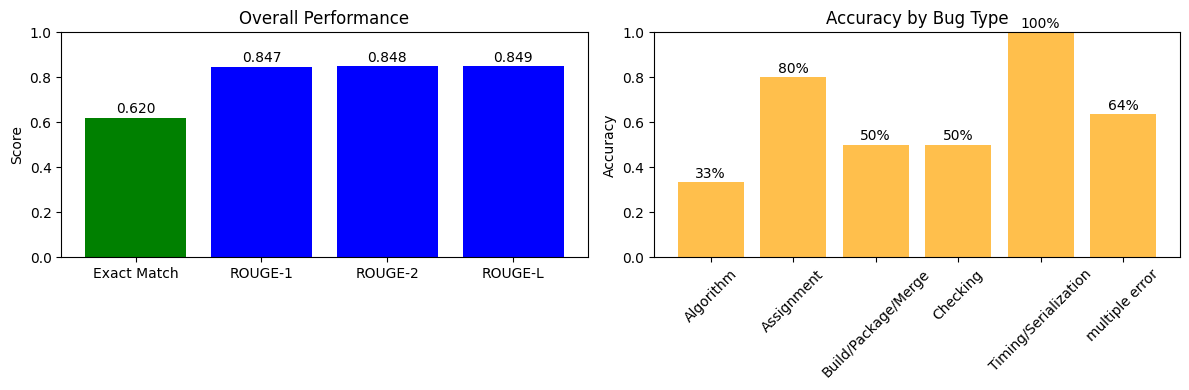

✅ Plot saved to: /kaggle/working/rag_validation_plot.png


In [18]:
# ============================================================
# CELL 12: VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall metrics
metrics = ['Exact Match', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
values = [
    exact_match_rate,
    rouge_scores['rouge1'],
    rouge_scores['rouge2'],
    rouge_scores['rougeL']
]
axes[0].bar(metrics, values, color=['green', 'blue', 'blue', 'blue'])
axes[0].set_title('Overall Performance')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Per-bug-type
bug_rates = bug_stats['rate']
bug_names = bug_stats.index.tolist()
axes[1].bar(bug_names, bug_rates, color='orange', alpha=0.7)
axes[1].set_title('Accuracy by Bug Type')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(bug_rates):
    axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center')

plt.tight_layout()
plt.savefig('/kaggle/working/rag_validation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to: /kaggle/working/rag_validation_plot.png")

In [20]:
# ============================================================
# CELL 14: QUICK COMPARISON: BASE VS RAG
# ============================================================
print("="*60)
print("📊 QUICK COMPARISON: BASE MODEL VS RAG-ENHANCED")
print("="*60)

# You can manually input these from previous runs
# This cell assumes you have the baseline results from your original notebook

# From your original validation run:
base_exact_match = 0.36  # 36.00% from your notebook
base_rouge1 = 0.9527
base_rouge2 = 0.9421
base_rougeL = 0.9474
base_bleu = 83.73

print(f"""
{'Metric':<20} {'Base Model':<15} {'RAG Model':<15} {'Change':<10}
{'-'*60}
{'Exact Match':<20} {base_exact_match*100:>6.1f}%      {exact_match_rate*100:>6.1f}%      {((exact_match_rate - base_exact_match)*100):>+6.1f}%
{'ROUGE-1':<20} {base_rouge1:<15.4f} {rouge_scores['rouge1']:<15.4f} {rouge_scores['rouge1'] - base_rouge1:>+8.4f}
{'ROUGE-2':<20} {base_rouge2:<15.4f} {rouge_scores['rouge2']:<15.4f} {rouge_scores['rouge2'] - base_rouge2:>+8.4f}
{'ROUGE-L':<20} {base_rougeL:<15.4f} {rouge_scores['rougeL']:<15.4f} {rouge_scores['rougeL'] - base_rougeL:>+8.4f}
{'SacreBLEU':<20} {base_bleu:<15.2f} {bleu_score['score']:<15.2f} {bleu_score['score'] - base_bleu:>+8.2f}
""")

📊 QUICK COMPARISON: BASE MODEL VS RAG-ENHANCED

Metric               Base Model      RAG Model       Change    
------------------------------------------------------------
Exact Match            36.0%        62.0%       +26.0%
ROUGE-1              0.9527          0.8470           -0.1057
ROUGE-2              0.9421          0.8484           -0.0937
ROUGE-L              0.9474          0.8494           -0.0980
SacreBLEU            83.73           59.71             -24.02

